In [1]:
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.append(project_root)

ULA simulation

In [2]:
from src.simulator import ULASimulator

In [3]:
sim = ULASimulator(M=8, fc=2.4e9)

X, A, S = sim.generate_signal(sources_theta=[20, -40], snr_db=10, n_snapshots=100)

print(f"Size of matrix X (M antennas x N snapshots): {X.shape}")

Size of matrix X (M antennas x N snapshots): (8, 100)


Delay-and-Sum testing

In [4]:
from src.algorithms import Beamformer
import numpy as np
import matplotlib.pyplot as plt

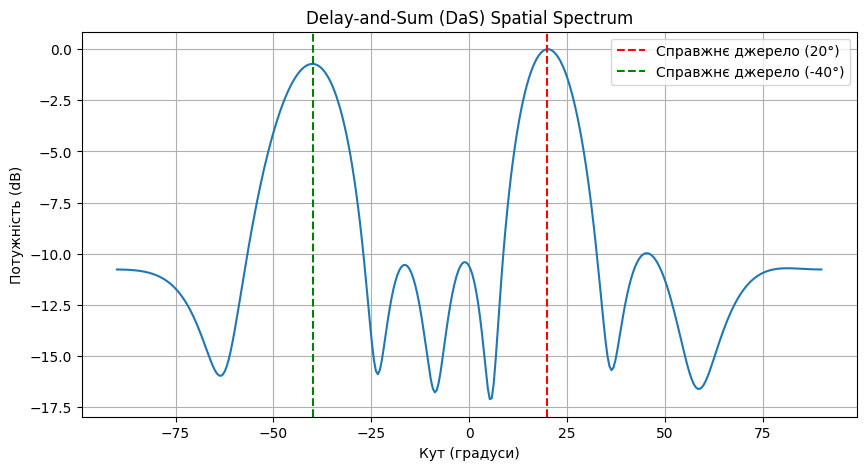

In [5]:
bf = Beamformer(sim)
R = bf.compute_covariance(X)

scan_angles = np.linspace(-90, 90, 360) 
spectrum = bf.run_das(R, scan_angles)

spectrum_db = 10 * np.log10(spectrum / np.max(spectrum))

plt.figure(figsize=(10, 5))
plt.plot(scan_angles, spectrum_db)
plt.axvline(20, color='r', linestyle='--', label='Справжнє джерело (20°)')
plt.axvline(-40, color='g', linestyle='--', label='Справжнє джерело (-40°)')
plt.title("Delay-and-Sum (DaS) Spatial Spectrum")
plt.xlabel("Кут (градуси)")
plt.ylabel("Потужність (dB)")
plt.legend()
plt.grid(True)
plt.show()

Comparison DaS vs MVDR

In [9]:
angles = [10, 15] 
sim = ULASimulator(M=10, fc=2.4e9)
X, _, _ = sim.generate_signal(sources_theta=angles, snr_db=20, n_snapshots=500)

bf = Beamformer(sim)
R = bf.compute_covariance(X)
scan_angles = np.linspace(-90, 90, 500)

spectrum_das = bf.run_das(R, scan_angles)
spectrum_mvdr = bf.run_mvdr(R, scan_angles)

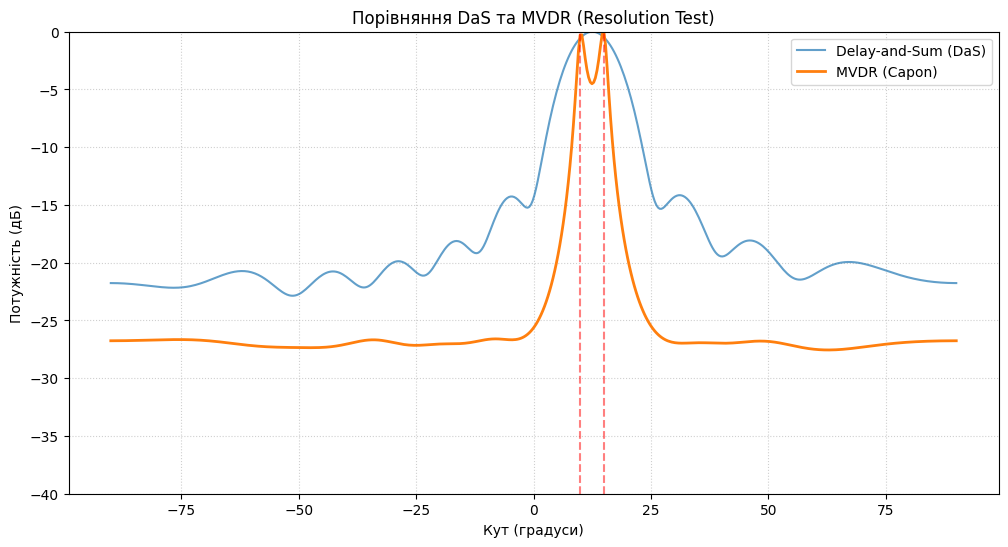

In [10]:
def to_db(s):
    return 10 * np.log10(s / np.max(s))

plt.figure(figsize=(12, 6))
plt.plot(scan_angles, to_db(spectrum_das), label='Delay-and-Sum (DaS)', alpha=0.7)
plt.plot(scan_angles, to_db(spectrum_mvdr), label='MVDR (Capon)', linewidth=2)

for a in angles:
    plt.axvline(a, color='red', linestyle='--', alpha=0.5)

plt.title("Порівняння DaS та MVDR (Resolution Test)")
plt.xlabel("Кут (градуси)")
plt.ylabel("Потужність (дБ)")
plt.ylim([-40, 0])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Beamwidth comparison

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.simulator import ULASimulator
from src.algorithms import Beamformer
from src.metrics import calculate_beamwidth

In [6]:
sim = ULASimulator(M=10, fc=2.4e9)
X, _, _ = sim.generate_signal(sources_theta=[0], snr_db=15,  n_snapshots=500)

bf = Beamformer(sim)
R = bf.compute_covariance(X)
scan_angles = np.linspace(-90, 90, 1000)

In [7]:
spectrum_das = bf.run_das(R, scan_angles)
spectrum_mvdr = bf.run_mvdr(R, scan_angles)

bw_das = calculate_beamwidth(spectrum_das, scan_angles)
bw_mvdr = calculate_beamwidth(spectrum_mvdr, scan_angles)

print(f"Results of the experiment:")
print(f"Beamwidth DaS:  {bw_das:.2f} degrees")
print(f"Beamwidth MVDR: {bw_mvdr:.2f} degrees")

Results of the experiment:
Beamwidth DaS:  10.27 degrees
Beamwidth MVDR: 0.90 degrees


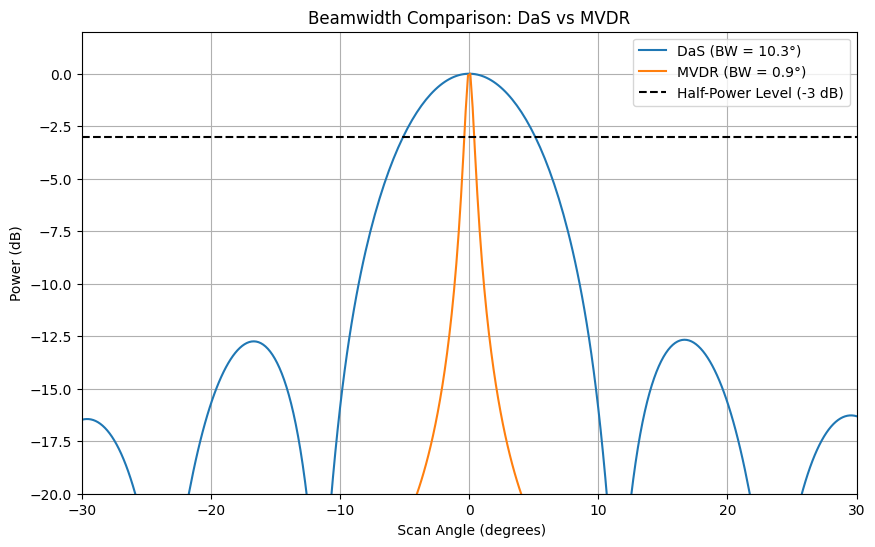

In [8]:
def to_db(s):
    return 10 * np.log10(s / np.max(s))

plt.figure(figsize=(10, 6))
plt.plot(scan_angles, to_db(spectrum_das), label=f'DaS (BW = {bw_das:.1f}°)')
plt.plot(scan_angles, to_db(spectrum_mvdr), label=f'MVDR (BW = {bw_mvdr:.1f}°)')

# Малюємо лінію рівня -3 дБ
plt.axhline(-3, color='black', linestyle='--', label='Half-Power Level (-3 dB)')

plt.title("Beamwidth Comparison: DaS vs MVDR")
plt.xlabel(" Scan Angle (degrees)")
plt.ylabel("Power (dB)")
plt.xlim([-30, 30])
plt.ylim([-20, 2])
plt.legend()
plt.grid(True)
plt.show()

Comparison of beamwidth depending on the number of anthenas

Починаємо експеримент...
Antennas:  4 | DaS Beamwidth: 26.47° | MVDR Beamwidth:  2.88°
Antennas:  8 | DaS Beamwidth: 12.88° | MVDR Beamwidth:  1.08°
Antennas: 12 | DaS Beamwidth:  8.55° | MVDR Beamwidth:  0.63°
Antennas: 16 | DaS Beamwidth:  6.39° | MVDR Beamwidth:  0.45°
Antennas: 24 | DaS Beamwidth:  4.32° | MVDR Beamwidth:  0.27°
Antennas: 32 | DaS Beamwidth:  3.33° | MVDR Beamwidth:  0.27°


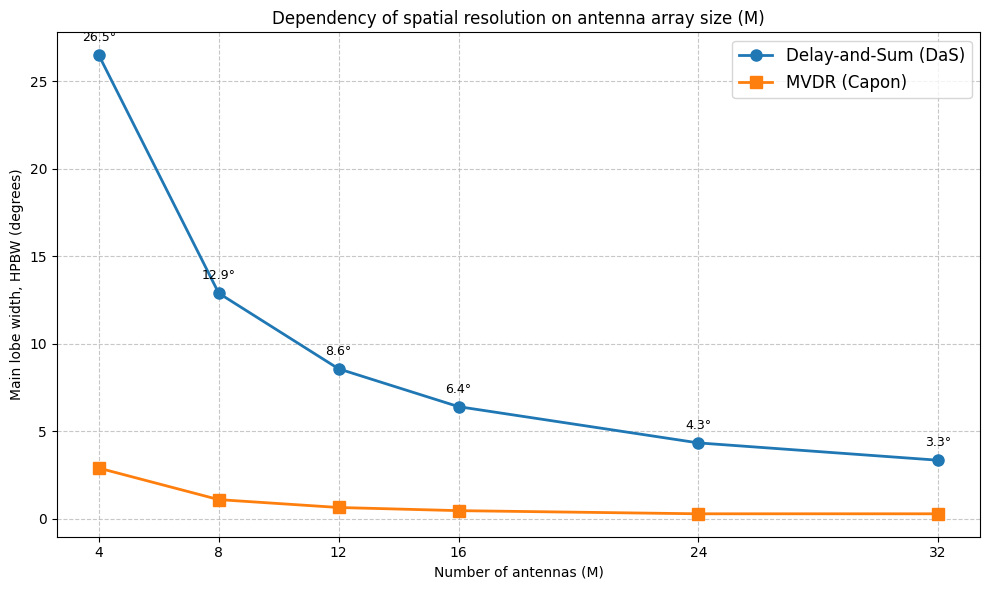

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from src.simulator import ULASimulator
from src.algorithms import Beamformer
from src.metrics import calculate_beamwidth

num_antennas_list = [4, 8, 12, 16, 24, 32] 
beamwidths_das = []
beamwidths_mvdr = []

snr = 15
snapshots = 500
source_angle = [0]
scan_angles = np.linspace(-90, 90, 2000)

print("Починаємо експеримент...")

for m in num_antennas_list:
    sim = ULASimulator(M=m, fc=2.4e9)
    X, _, _ = sim.generate_signal(sources_theta=source_angle, snr_db=snr, n_snapshots=snapshots)
    
    bf = Beamformer(sim)
    R = bf.compute_covariance(X)

    spectrum_das = bf.run_das(R, scan_angles)
    spectrum_mvdr = bf.run_mvdr(R, scan_angles)

    bw_das = calculate_beamwidth(spectrum_das, scan_angles)
    bw_mvdr = calculate_beamwidth(spectrum_mvdr, scan_angles)
    
    beamwidths_das.append(bw_das)
    beamwidths_mvdr.append(bw_mvdr)
    
    print(f"Antennas: {m:2d} | DaS Beamwidth: {bw_das:5.2f}° | MVDR Beamwidth: {bw_mvdr:5.2f}°")

plt.figure(figsize=(10, 6))

plt.plot(num_antennas_list, beamwidths_das, marker='o', linestyle='-', 
         linewidth=2, markersize=8, label='Delay-and-Sum (DaS)', color='#1f77b4')
plt.plot(num_antennas_list, beamwidths_mvdr, marker='s', linestyle='-', 
         linewidth=2, markersize=8, label='MVDR (Capon)', color='#ff7f0e')

for i, txt in enumerate(beamwidths_das):
    plt.annotate(f"{txt:.1f}°", (num_antennas_list[i], beamwidths_das[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title("Dependency of spatial resolution on antenna array size (M)")
plt.xlabel("Number of antennas (M)")
plt.ylabel("Main lobe width, HPBW (degrees)")
plt.xticks(num_antennas_list)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

SSL comparison

SLL for DaS:  -12.92 dB
SLL for MVDR: -29.10 dB


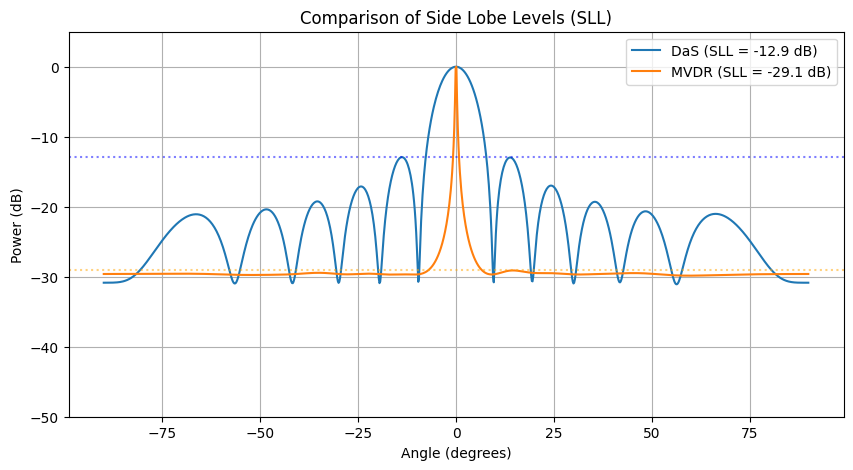

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.simulator import ULASimulator
from src.algorithms import Beamformer
from src.metrics import calculate_sll

sim = ULASimulator(M=12, fc=2.4e9)
X, _, _ = sim.generate_signal(sources_theta=[0], snr_db=20, n_snapshots=500)

bf = Beamformer(sim)
R = bf.compute_covariance(X)
scan_angles = np.linspace(-90, 90, 1000)

spec_das = bf.run_das(R, scan_angles)
spec_mvdr = bf.run_mvdr(R, scan_angles)

sll_das = calculate_sll(spec_das)
sll_mvdr = calculate_sll(spec_mvdr)

print(f"SLL for DaS:  {sll_das:.2f} dB")
print(f"SLL for MVDR: {sll_mvdr:.2f} dB")

def to_db(s): return 10 * np.log10(s / np.max(s))

plt.figure(figsize=(10, 5))
plt.plot(scan_angles, to_db(spec_das), label=f'DaS (SLL = {sll_das:.1f} dB)')
plt.plot(scan_angles, to_db(spec_mvdr), label=f'MVDR (SLL = {sll_mvdr:.1f} dB)')

plt.axhline(sll_das, color='blue', linestyle=':', alpha=0.5)
plt.axhline(sll_mvdr, color='orange', linestyle=':', alpha=0.5)

plt.title("Comparison of Side Lobe Levels (SLL)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Power (dB)")
plt.ylim([-50, 5])
plt.legend()
plt.grid(True)
plt.show()

Grating Lobes

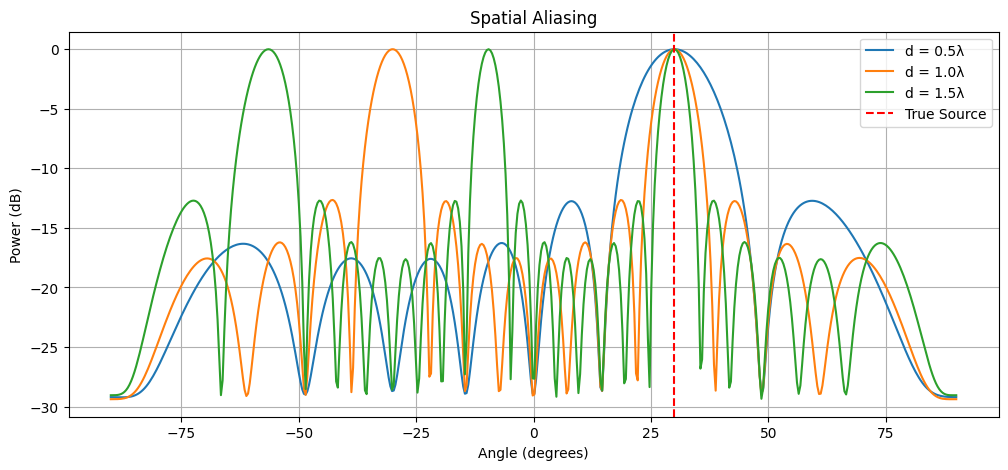

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.simulator import ULASimulator
from src.algorithms import Beamformer

spacing_factors = [0.5, 1.0, 1.5]
scan_angles = np.linspace(-90, 90, 500)

plt.figure(figsize=(12, 5))

for d_factor in spacing_factors:
    sim = ULASimulator(M=8, fc=2.4e9, spacing_factor=d_factor)
    X, _, _ = sim.generate_signal(sources_theta=[30], snr_db=20, n_snapshots=500)
    
    bf = Beamformer(sim)
    R = bf.compute_covariance(X)
    spectrum = bf.run_das(R, scan_angles)
    
    spec_db = 10 * np.log10(spectrum / np.max(spectrum))
    plt.plot(scan_angles, spec_db, label=f'd = {d_factor}λ')

plt.axvline(30, color='red', linestyle='--', label='True Source')
plt.title("Spatial Aliasing")
plt.xlabel("Angle (degrees)")
plt.ylabel("Power (dB)")
plt.legend()
plt.grid(True)
plt.show()

Snapshots

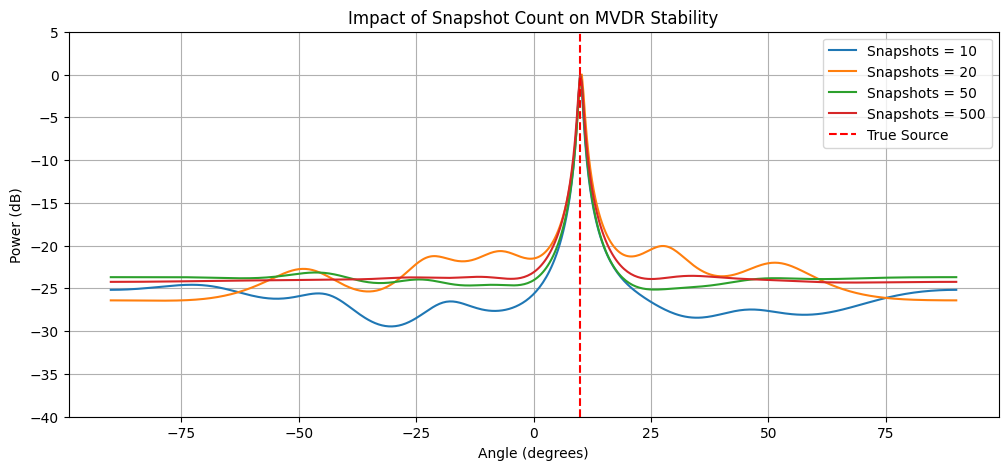

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from src.simulator import ULASimulator
from src.algorithms import Beamformer

snapshot_counts = [10, 20, 50, 500]
scan_angles = np.linspace(-90, 90, 500)

plt.figure(figsize=(12, 5))

sim = ULASimulator(M=8, fc=2.4e9)

for N in snapshot_counts:
    X, _, _ = sim.generate_signal(sources_theta=[10], n_snapshots=N, snr_db=15)
    
    bf = Beamformer(sim)
    R = bf.compute_covariance(X)

    spectrum = bf.run_mvdr(R, scan_angles)
    
    spec_db = 10 * np.log10(spectrum / np.max(spectrum))
    plt.plot(scan_angles, spec_db, label=f'Snapshots = {N}')

plt.axvline(10, color='red', linestyle='--', label='True Source')
plt.title("Impact of Snapshot Count on MVDR Stability")
plt.xlabel("Angle (degrees)")
plt.ylabel("Power (dB)")
plt.ylim([-40, 5])
plt.legend()
plt.grid(True)
plt.show()